Mean Squared Error: 7.827784347679279
R-squared: 0.999298496910247


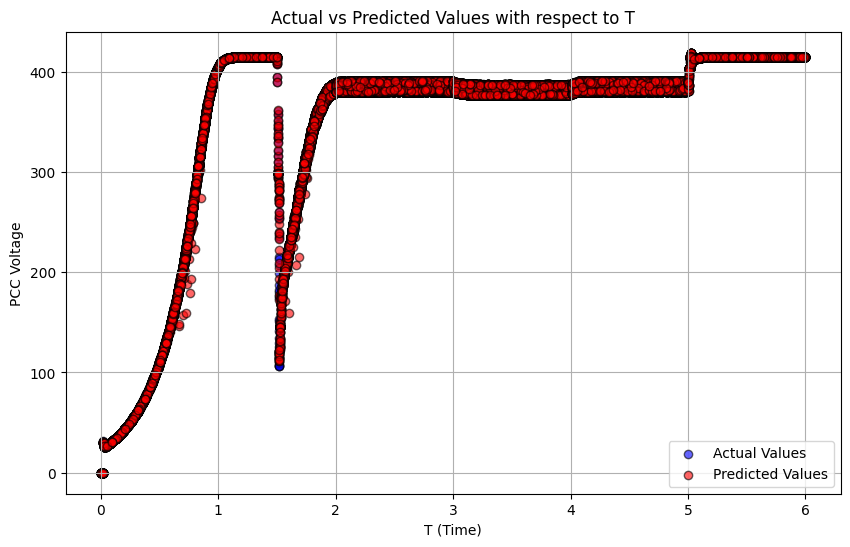

In [10]:
import pandas as pd
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt 

def load_data_from_folder(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    data_list = [pd.read_csv(os.path.join(folder_path, file)) for file in csv_files]
    combined_data = pd.concat(data_list, ignore_index=True)
    return combined_data

train_folder = r'C:\Users\ACER\Desktop\as\Training'
test_folder = r'C:\Users\ACER\Desktop\as\Testing'

train_data = load_data_from_folder(train_folder)
test_data = load_data_from_folder(test_folder)
# Define input features and output for training and testing
X_train = train_data[['T', 'W', 'L']]
y_train = train_data['V']

X_test = test_data[['T', 'W', 'L']]
y_test = test_data['V']

# Initialize and fit Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

# Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Save the predictions to a CSV file
output = pd.DataFrame({'T': test_data['T'], 'W': test_data['W'], 'L': test_data['L'], 'Actual_V': y_test, 'Predicted_V': y_pred})
output.to_csv('predictions_rf.csv', index=False)

def plot_predictions_vs_T(X_test, y_test, y_pred, T_column_name='T'):
    """
    Function to plot both actual and predicted values against 'T' values.
    
    Args:
    - X_test: DataFrame containing test features.
    - y_test: Actual values.
    - y_pred: Array of predicted values.
    - T_column_name: Name of the 'T' column in X_test.
    """
    # Extract the 'T' column from the test set
    T_values = X_test[T_column_name]
    
    # Plot actual values vs T
    plt.figure(figsize=(10, 6))
    plt.scatter(T_values, y_test, color='blue', label='Actual Values', edgecolor='k', alpha=0.6)
    
    # Plot predicted values vs T
    plt.scatter(T_values, y_pred, color='red', label='Predicted Values', edgecolor='k', alpha=0.6)
    
    # Adding titles and labels
    plt.title("Actual vs Predicted Values with respect to T")
    plt.xlabel('T (Time)')
    plt.ylabel('PCC Voltage')
    
    # Add a legend to differentiate actual and predicted values
    plt.legend()
    
    # Display grid
    plt.grid(True)
    
    # Show the plot
    plt.show()

# Call the function with the actual and predicted values
plot_predictions_vs_T(X_test, y_test, y_pred, T_column_name='T')